# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import os
import shutil

import numpy as np
import pandas as pd

import imageio
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
from torchvision import datasets, transforms

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

import kagglehub

from tqdm.notebook import tqdm_notebook

import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 60

%matplotlib inline  

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [3]:
PATH = 'kaggle'

os.makedirs(PATH, exist_ok=True)

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [4]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

if os.path.exists(images_path):
    for item in os.listdir(images_path):
        src = os.path.join(images_path, item)
        dst = os.path.join(PATH, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

In [5]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")

if os.path.exists(attrs_path):
    for item in os.listdir(attrs_path):
        src = os.path.join(attrs_path, item)
        dst = os.path.join(PATH, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

In [6]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

DATASET_PATH = "kaggle/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "kaggle/lfw_attributes.txt"

In [7]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [8]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [9]:
RANDOM_SEED = 42

X_train, X_val, attrs_train, attrs_val = train_test_split(
    images, attrs, test_size=0.15, random_state=RANDOM_SEED
)

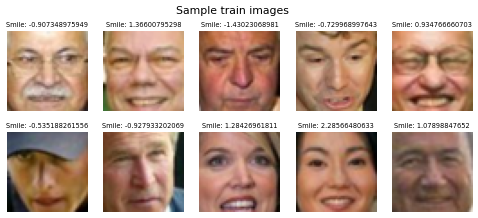

In [10]:
# Визуализация (посмотрим на аттрибут Smiling)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f"Smile: {attrs_train.iloc[i]['Smiling']}", fontsize=8)
    ax.axis('off')
plt.suptitle('Sample train images', fontsize=13)

plt.show();

In [11]:
def to_tensor(imgs: np.ndarray) -> torch.FloatTensor:
    """
    Преобразование массива numpy в тензор Pytorch
    """
    return torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0

X_train_t = to_tensor(X_train)
X_val_t = to_tensor(X_val)

BATCH_SIZE = 64
train_dataset = data_utils.TensorDataset(X_train_t)
val_dataset = data_utils.TensorDataset(X_val_t)

# Даталоадеры
train_loader = data_utils.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = data_utils.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f'Train tensor:   {X_train_t.shape}')
print(f'Val tensor:     {X_val_t.shape}')

Train tensor:   torch.Size([11171, 3, 45, 45])
Val tensor:     torch.Size([1972, 3, 45, 45])


## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.


In [12]:
dim_code = 256  # размер латентного вектора
IMG_SHAPE = (3, 45, 45)  # форма входного изображени
INPUT_DIM = 3 * 45 * 45  # общее количество пикселей

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [13]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, dim_code=dim_code):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, dim_code), 
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 128 * 6 * 6), nn.ReLU(),
            nn.Unflatten(1, (128, 6, 6)),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=0), 
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=0), 
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        
        return reconstruction, latent_code

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

In [14]:
criterion = nn.MSELoss()

autoencoder = Autoencoder().to(device)

optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

Epoch  1/60 | Train Loss: 0.0194 | Val Loss: 0.0105
Epoch  2/60 | Train Loss: 0.0086 | Val Loss: 0.0077
Epoch  3/60 | Train Loss: 0.0067 | Val Loss: 0.0062
Epoch  4/60 | Train Loss: 0.0056 | Val Loss: 0.0055
Epoch  5/60 | Train Loss: 0.0049 | Val Loss: 0.0050
Epoch  6/60 | Train Loss: 0.0044 | Val Loss: 0.0044
Epoch  7/60 | Train Loss: 0.0041 | Val Loss: 0.0040
Epoch  8/60 | Train Loss: 0.0039 | Val Loss: 0.0039
Epoch  9/60 | Train Loss: 0.0036 | Val Loss: 0.0037
Epoch 10/60 | Train Loss: 0.0035 | Val Loss: 0.0036
Epoch 11/60 | Train Loss: 0.0033 | Val Loss: 0.0033
Epoch 12/60 | Train Loss: 0.0032 | Val Loss: 0.0033
Epoch 13/60 | Train Loss: 0.0031 | Val Loss: 0.0032
Epoch 14/60 | Train Loss: 0.0030 | Val Loss: 0.0029
Epoch 15/60 | Train Loss: 0.0029 | Val Loss: 0.0029
Epoch 16/60 | Train Loss: 0.0027 | Val Loss: 0.0027
Epoch 17/60 | Train Loss: 0.0027 | Val Loss: 0.0028
Epoch 18/60 | Train Loss: 0.0026 | Val Loss: 0.0026
Epoch 19/60 | Train Loss: 0.0025 | Val Loss: 0.0026
Epoch 20/60 

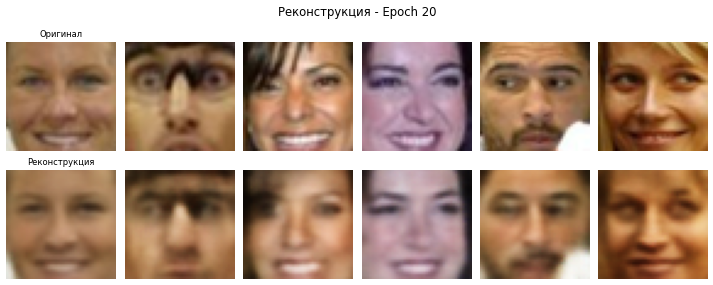

Epoch 21/60 | Train Loss: 0.0024 | Val Loss: 0.0025
Epoch 22/60 | Train Loss: 0.0024 | Val Loss: 0.0025
Epoch 23/60 | Train Loss: 0.0024 | Val Loss: 0.0025
Epoch 24/60 | Train Loss: 0.0023 | Val Loss: 0.0026
Epoch 25/60 | Train Loss: 0.0023 | Val Loss: 0.0025
Epoch 26/60 | Train Loss: 0.0023 | Val Loss: 0.0025
Epoch 27/60 | Train Loss: 0.0023 | Val Loss: 0.0024
Epoch 28/60 | Train Loss: 0.0022 | Val Loss: 0.0023
Epoch 29/60 | Train Loss: 0.0022 | Val Loss: 0.0024
Epoch 30/60 | Train Loss: 0.0022 | Val Loss: 0.0024
Epoch 31/60 | Train Loss: 0.0022 | Val Loss: 0.0023
Epoch 32/60 | Train Loss: 0.0022 | Val Loss: 0.0023
Epoch 33/60 | Train Loss: 0.0022 | Val Loss: 0.0023
Epoch 34/60 | Train Loss: 0.0021 | Val Loss: 0.0023
Epoch 35/60 | Train Loss: 0.0021 | Val Loss: 0.0023
Epoch 36/60 | Train Loss: 0.0021 | Val Loss: 0.0022
Epoch 37/60 | Train Loss: 0.0021 | Val Loss: 0.0022
Epoch 38/60 | Train Loss: 0.0021 | Val Loss: 0.0022
Epoch 39/60 | Train Loss: 0.0021 | Val Loss: 0.0022
Epoch 40/60 

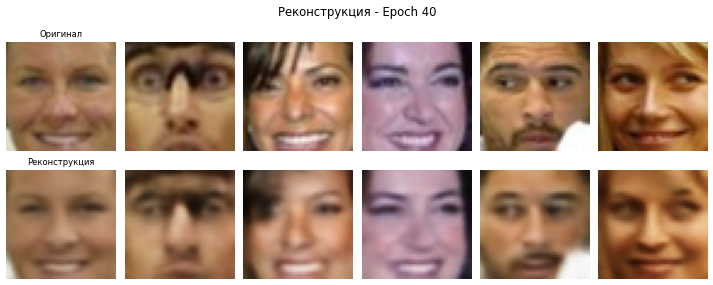

Epoch 41/60 | Train Loss: 0.0020 | Val Loss: 0.0022
Epoch 42/60 | Train Loss: 0.0021 | Val Loss: 0.0022
Epoch 43/60 | Train Loss: 0.0020 | Val Loss: 0.0022
Epoch 44/60 | Train Loss: 0.0020 | Val Loss: 0.0022
Epoch 45/60 | Train Loss: 0.0020 | Val Loss: 0.0022
Epoch 46/60 | Train Loss: 0.0020 | Val Loss: 0.0023
Epoch 47/60 | Train Loss: 0.0020 | Val Loss: 0.0022
Epoch 48/60 | Train Loss: 0.0020 | Val Loss: 0.0022
Epoch 49/60 | Train Loss: 0.0020 | Val Loss: 0.0021
Epoch 50/60 | Train Loss: 0.0020 | Val Loss: 0.0021
Epoch 51/60 | Train Loss: 0.0020 | Val Loss: 0.0021
Epoch 52/60 | Train Loss: 0.0020 | Val Loss: 0.0024
Epoch 53/60 | Train Loss: 0.0020 | Val Loss: 0.0021
Epoch 54/60 | Train Loss: 0.0019 | Val Loss: 0.0021
Epoch 55/60 | Train Loss: 0.0019 | Val Loss: 0.0021
Epoch 56/60 | Train Loss: 0.0019 | Val Loss: 0.0021
Epoch 57/60 | Train Loss: 0.0019 | Val Loss: 0.0021
Epoch 58/60 | Train Loss: 0.0019 | Val Loss: 0.0021
Epoch 59/60 | Train Loss: 0.0019 | Val Loss: 0.0021
Epoch 60/60 

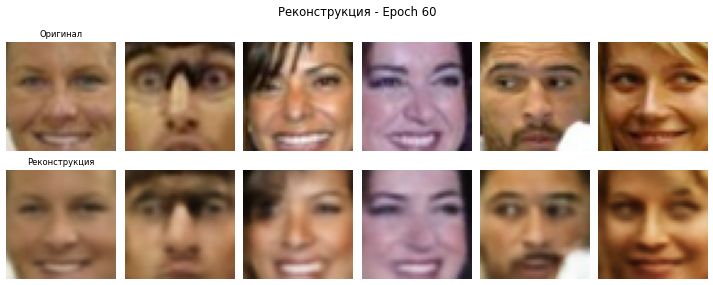

In [15]:
EPOCHS = 60
train_losses, val_losses = [], []  # история

VIZ_N = 6  # количество изображений для визуализации
viz_imgs = X_val_t[:VIZ_N].to(device) # изорбражения для сравнения

for epoch in range(1, EPOCHS + 1):
    # Трейн
    autoencoder.train()
    train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        
        optimizer.zero_grad()
        reconstruction, _ = autoencoder(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Валидация
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            reconstruction, _ = autoencoder(batch)
            val_loss += criterion(reconstruction, batch).item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}')

    # Визуализация реконструкций каждые 20 эпох
    if epoch % 20 == 0:
        with torch.no_grad():
            reconstructions, _ = autoencoder(viz_imgs)

        fig, axes = plt.subplots(2, VIZ_N, figsize=(12, 5))
        for i in range(VIZ_N):
            # Оригинал
            axes[0, i].imshow(viz_imgs[i].cpu().permute(1, 2, 0))
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Оригинал', fontsize=10)
            
            # Реконструкция
            axes[1, i].imshow(reconstructions[i].cpu().permute(1, 2, 0))
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Реконструкция', fontsize=10)

        plt.suptitle(f'Реконструкция - Epoch {epoch}', fontsize=14) 
        plt.tight_layout()
        plt.show()

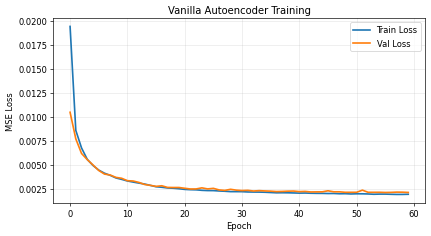

In [16]:
# Визуализация

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Vanilla Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show();

Что вы можете сказать про результат?

Модель обучается стабильно, лосс (MSE) снижается, переобучения не наблюдается.  
После реконструкции лица остаются узнаваемыми, но немного размытыми.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [17]:
autoencoder.eval()

# Статистика латентного пространства для декодера
all_latents = []
with torch.no_grad():
    for batch in train_loader:
        _, z = autoencoder(batch[0].to(device))
        all_latents.append(z.cpu().numpy())
all_latents = np.concatenate(all_latents)
mu, sigma = all_latents.mean(axis=0), all_latents.std(axis=0)

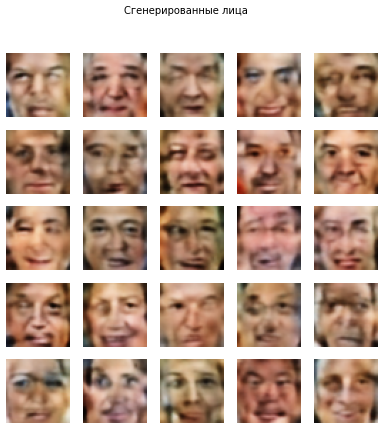

In [18]:
# Сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, dim_code) * sigma + mu
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

# Декодирование случайных векторов в изображения
with torch.no_grad():
    generated = autoencoder.decoder(z_tensor).cpu()

# Визуализация сгенерированных лиц
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].permute(1, 2, 0))
    ax.axis('off')
plt.suptitle('Сгенерированные лица')

plt.show();

Крипово ☺

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

In [19]:
# <img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [20]:
smiling_mask = attrs_train['Smiling'] > 0.5  # с улыбками
neutral_mask = attrs_train['Smiling'] < -0.5  # без улыбок

smiling_positions = np.where(smiling_mask)[0]
neutral_positions = np.where(neutral_mask)[0]

print(f'Найдено улыбающихся: {len(smiling_positions)}')
print(f'Найдено грустных:    {len(neutral_positions)}')

# Позиции первых 15 изображений
smiling_positions = smiling_positions[:15]
neutral_positions = neutral_positions[:15]

# Подготовка выбранных изображений
smiling_imgs = X_train_t[smiling_positions].to(device)
neutral_imgs = X_train_t[neutral_positions].to(device)

autoencoder.eval()

with torch.no_grad():
    # Латентные векторы для улыбающихся и неулыбающихся
    _, smiling_latent = autoencoder(smiling_imgs)
    _, neutral_latent = autoencoder(neutral_imgs)
    
    # Вектор для улыбки
    smile_vector = smiling_latent.mean(dim=0) - neutral_latent.mean(dim=0)
    print(f'Норма вектора улыбки: {smile_vector.norm().item():.4f}')

Найдено улыбающихся: 3411
Найдено грустных:    4999
Норма вектора улыбки: 4.9735


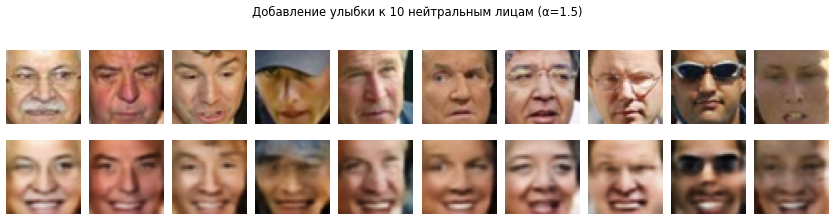

In [21]:
# Визуализация (добавления улыбки для N_SAMPLES изображений)

N_SAMPLES = 10

test_neutral_positions = neutral_positions[:N_SAMPLES]
test_neutral_imgs = X_train_t[test_neutral_positions].to(device)

ALPHA = 1.5

with torch.no_grad():
    test_codes = autoencoder.encoder(test_neutral_imgs)
    smiling_codes = test_codes + ALPHA * smile_vector.unsqueeze(0)  # добавления вектора улыбки интинсивности альфа
    reconstructed = autoencoder.decoder(smiling_codes).cpu()
    originals_cpu = test_neutral_imgs.cpu()

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(14, 4))
for i in range(N_SAMPLES):
    axes[0, i].imshow(originals_cpu[i].permute(1, 2, 0).clamp(0, 1))
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).clamp(0, 1))
    axes[1, i].axis('off')

plt.suptitle(f'Добавление улыбки к 10 нейтральным лицам (α={ALPHA})', fontsize=14)
plt.tight_layout()

plt.show();

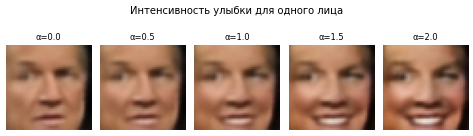

In [22]:
# Попробуем разные интенсивности улыбки

alphas = [0.0, 0.5, 1.0, 1.5, 2.0]
test_person = test_neutral_imgs[5:6]

fig, axes = plt.subplots(1, len(alphas), figsize=(8, 2.5))
with torch.no_grad():
    code = autoencoder.encoder(test_person)
    for j, alpha in enumerate(alphas):
        out = autoencoder.decoder(code + alpha * smile_vector.unsqueeze(0)).cpu()
        axes[j].imshow(out[0].permute(1, 2, 0).clamp(0, 1))
        axes[j].set_title(f'α={alpha}', fontsize=10)
        axes[j].axis('off')

plt.suptitle('Интенсивность улыбки для одного лица', fontsize=12)
plt.tight_layout()

plt.show();

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [23]:
BATCH_SIZE = 32

# MNIST Dataset
train_dataset = datasets.MNIST(
    root='./mnist_data/',
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = datasets.MNIST(
    root='./mnist_data/',
    train=False,
    transform=transforms.ToTensor(),
    download=False
)

# Даталоадеры
train_loader = data_utils.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = data_utils.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [24]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2), 
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(hidden_dim//2, latent_dim)
        self.fc_logsigma = nn.Linear(hidden_dim//2, latent_dim)

        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2), 
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), 
            nn.Sigmoid()
        )

    def encode(self, x):
        
        h = self.encoder_net(x.view(x.size(0), -1))
        return self.fc_mu(h), self.fc_logsigma(h)  # возвращаем параметры распределения

    # Reparameterization trick
    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z):
        return self.decoder_net(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [25]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

In [26]:
torch.cuda.empty_cache() 

latent_dim = 32

vae_model = VAE(latent_dim=latent_dim).to(device)

optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

In [27]:
EPOCHS = 30

train_losses, val_losses = [], []

for epoch in tqdm_notebook(range(1, EPOCHS + 1)):
    # Трейн
    vae_model.train()
    train_loss = 0.0
    for x, _ in train_loader:
        x = x.to(device)
        
        optimizer.zero_grad()
        mu, logsigma, reconstruction = vae_model(x)
        loss = loss_vae(x, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Валидация
    vae_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            mu, logsigma, reconstruction = vae_model(x)
            val_loss += loss_vae(x, mu, logsigma, reconstruction).item()
    
    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch  1/30 | Train Loss: 5174.0313 | Val Loss: 4276.2917
Epoch  2/30 | Train Loss: 4168.1267 | Val Loss: 3931.4788
Epoch  3/30 | Train Loss: 3988.1888 | Val Loss: 3827.0985
Epoch  4/30 | Train Loss: 3895.8645 | Val Loss: 3774.1361
Epoch  5/30 | Train Loss: 3840.3877 | Val Loss: 3746.0097
Epoch  6/30 | Train Loss: 3790.9171 | Val Loss: 3665.4140
Epoch  7/30 | Train Loss: 3724.1718 | Val Loss: 3586.7188
Epoch  8/30 | Train Loss: 3654.1065 | Val Loss: 3544.7675
Epoch  9/30 | Train Loss: 3620.4499 | Val Loss: 3504.5160
Epoch 10/30 | Train Loss: 3592.1729 | Val Loss: 3505.0109
Epoch 11/30 | Train Loss: 3574.0408 | Val Loss: 3524.5257
Epoch 12/30 | Train Loss: 3557.3854 | Val Loss: 3471.5992
Epoch 13/30 | Train Loss: 3542.3659 | Val Loss: 3474.1614
Epoch 14/30 | Train Loss: 3530.0876 | Val Loss: 3471.6002
Epoch 15/30 | Train Loss: 3521.9128 | Val Loss: 3462.9415
Epoch 16/30 | Train Loss: 3509.2668 | Val Loss: 3459.8312
Epoch 17/30 | Train Loss: 3502.3463 | Val Loss: 3446.6444
Epoch 18/30 | 

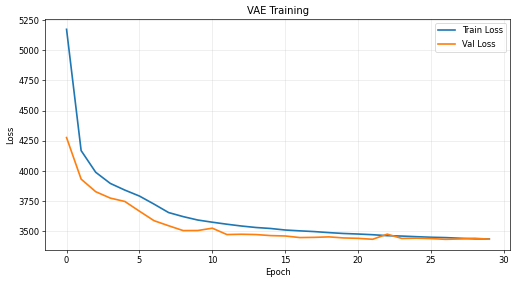

In [28]:
# Визуалиация

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show();

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [29]:
# Статистика латентного пространства
all_mu = []
vae_model.eval()
with torch.no_grad():
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        mu, _ = vae_model.encode(batch_x)
        all_mu.append(mu.cpu().numpy())

all_mu = np.concatenate(all_mu, axis=0)
mu_mean = all_mu.mean(axis=0)
mu_std = all_mu.std(axis=0)

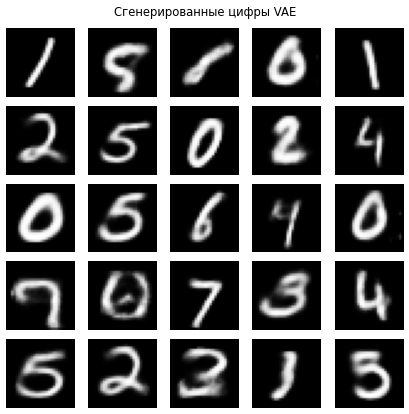

In [30]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
latent_dim = 32
z = np.array([np.random.normal(mu_mean, mu_std, latent_dim) for _ in range(25)])
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

with torch.no_grad():
    output = vae_model.decode(z_tensor).cpu()


generated_np = output.permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_np[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Сгенерированные цифры VAE', fontsize=14)
plt.tight_layout()

plt.show();

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [31]:
vae_model.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        mu, _ = vae_model.encode(X_batch.to(device))
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

In [32]:
latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

latents_2d = TSNE(n_components=2, random_state=42).fit_transform(latents)

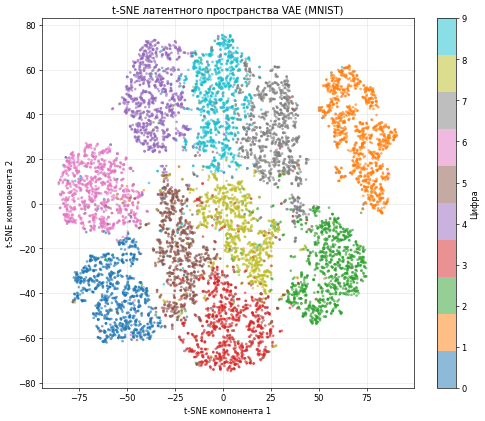

In [33]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    latents_2d[:, 0], 
    latents_2d[:, 1], 
    c=labels, cmap='tab10', 
    alpha=0.5, 
    s=5
)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t-SNE латентного пространства VAE (MNIST)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(alpha=0.3)

plt.show();

Что вы думаете о виде латентного представления?

Классы хорошо разделяются. Сформировались четкие кластеры для разных цифр.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.

In [34]:

# ![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

# ![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [35]:
class CVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=32, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2), 
            nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(hidden_dim//2, latent_dim)
        self.fc_logsigma = nn.Linear(hidden_dim//2, latent_dim)

        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim//2), 
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), 
            nn.Sigmoid()
        )

    def encode(self, x, y):
        one_hot = torch.nn.functional.one_hot(y, self.num_classes).float()
        x_flat = x.view(x.size(0), -1)
        h = self.encoder_net(torch.cat([x_flat, one_hot], dim=1))
        return self.fc_mu(h), self.fc_logsigma(h)

    def reparameterize(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, y):
        one_hot = torch.nn.functional.one_hot(y, self.num_classes).float()
        z_cond = torch.cat([z, one_hot], dim=1)
        return self.decoder_net(z_cond).view(-1, 1, 28, 28)

    def forward(self, x, y):
        mu, logsigma = self.encode(x, y)
        z = self.reparameterize(mu, logsigma)
        return mu, logsigma, self.decode(z, y)

In [36]:
torch.cuda.empty_cache()

latent_dim = 32

cvae_model = CVAE(latent_dim=latent_dim).to(device)

optimizer = optim.Adam(cvae_model.parameters(), lr=1e-3)

In [37]:
EPOCHS = 30

train_losses, val_losses = [], []

for epoch in tqdm_notebook(range(1, EPOCHS + 1)):
    # Трейн
    cvae_model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        mu, logsigma, reconstruction = cvae_model(x, y)
        loss = loss_vae(x, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Валидация
    cvae_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            mu, logsigma, reconstruction = cvae_model(x, y)
            val_loss += loss_vae(x, mu, logsigma, reconstruction).item()
    
    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch  1/30 | Train Loss: 4842.2039 | Val Loss: 3975.7019
Epoch  2/30 | Train Loss: 3981.9344 | Val Loss: 3774.6514
Epoch  3/30 | Train Loss: 3844.6000 | Val Loss: 3673.0522
Epoch  4/30 | Train Loss: 3691.8768 | Val Loss: 3534.4928
Epoch  5/30 | Train Loss: 3609.1621 | Val Loss: 3488.6279
Epoch  6/30 | Train Loss: 3564.9856 | Val Loss: 3463.3614
Epoch  7/30 | Train Loss: 3533.0440 | Val Loss: 3451.7244
Epoch  8/30 | Train Loss: 3510.4597 | Val Loss: 3439.2671
Epoch  9/30 | Train Loss: 3491.1309 | Val Loss: 3419.8674
Epoch 10/30 | Train Loss: 3475.4696 | Val Loss: 3411.4374
Epoch 11/30 | Train Loss: 3462.7041 | Val Loss: 3397.7158
Epoch 12/30 | Train Loss: 3449.2116 | Val Loss: 3414.3497
Epoch 13/30 | Train Loss: 3439.1497 | Val Loss: 3406.2763
Epoch 14/30 | Train Loss: 3429.0358 | Val Loss: 3401.2726
Epoch 15/30 | Train Loss: 3421.4700 | Val Loss: 3396.2048
Epoch 16/30 | Train Loss: 3412.7872 | Val Loss: 3392.9017
Epoch 17/30 | Train Loss: 3406.5613 | Val Loss: 3379.5109
Epoch 18/30 | 

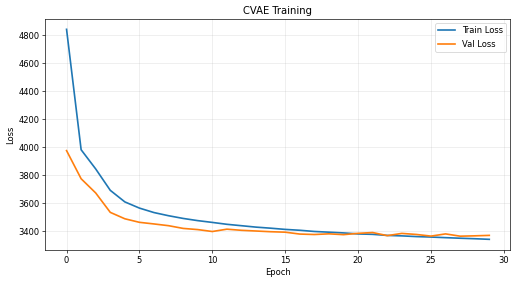

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CVAE Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show();

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

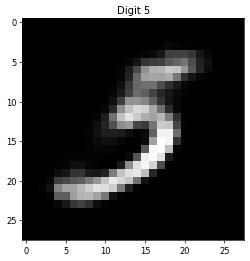

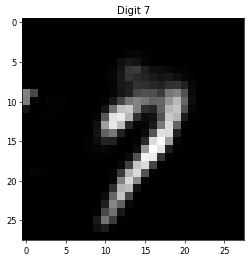

In [39]:
cvae_model.eval()
with torch.no_grad():
    z = torch.randn(1, latent_dim).to(device)
    for digit in [5, 7]:
        y = torch.tensor([digit]).to(device)
        recon = cvae_model.decode(z, y)
        plt.imshow(recon.cpu().squeeze(), cmap='gray')
        plt.title(f'Digit {digit}')
        plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [40]:
cvae_model.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        mu, _ = cvae_model.encode(X_batch.to(device), labels.to(device))
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

In [41]:
latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

latents_2d = TSNE(n_components=2, random_state=42).fit_transform(latents)

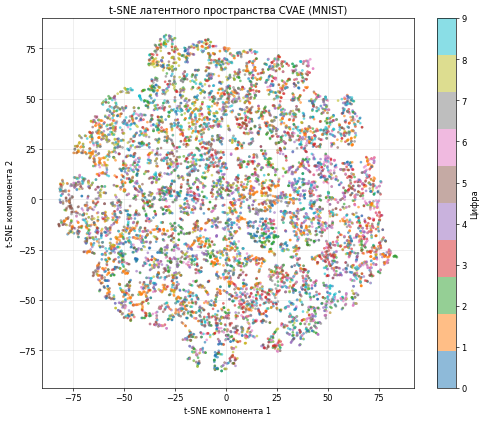

In [42]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    latents_2d[:, 0], 
    latents_2d[:, 1], 
    c=labels, cmap='tab10', 
    alpha=0.5, 
    s=5
)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t-SNE латентного пространства CVAE (MNIST)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(alpha=0.3)

plt.show();

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Результаты визуализации VAE и CVAE сильно отличаются.  
В отличии от визуализации VAE, где классы разбивались на четкие кластеры, в CVAE точки классов перемешаны.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [43]:
noise_factor = 0.5

# Добавление шума к изображениям
X_train_noisy = (X_train_t + noise_factor * torch.randn_like(X_train_t)).clamp(0, 1)
X_val_noisy = (X_val_t + noise_factor * torch.randn_like(X_val_t)).clamp(0, 1)

In [44]:
# Создание датасетов с зашумленными изображениями

BATCH_SIZE = 64

train_dataset_noisy = data_utils.TensorDataset(X_train_noisy, X_train_t)
val_dataset_noisy = data_utils.TensorDataset(X_val_noisy, X_val_t)

train_loader_noisy = data_utils.DataLoader(
    train_dataset_noisy,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader_noisy = data_utils.DataLoader(
    val_dataset_noisy,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [45]:
denoiser = Autoencoder().to(device)

optimizer = optim.Adam(denoiser.parameters(), lr=1e-3)

criterion = nn.MSELoss()

Epoch  1/60 | Train Loss: 0.0210 | Val Loss: 0.0119
Epoch  2/60 | Train Loss: 0.0101 | Val Loss: 0.0090
Epoch  3/60 | Train Loss: 0.0083 | Val Loss: 0.0081
Epoch  4/60 | Train Loss: 0.0075 | Val Loss: 0.0082
Epoch  5/60 | Train Loss: 0.0070 | Val Loss: 0.0069
Epoch  6/60 | Train Loss: 0.0066 | Val Loss: 0.0068
Epoch  7/60 | Train Loss: 0.0063 | Val Loss: 0.0066
Epoch  8/60 | Train Loss: 0.0061 | Val Loss: 0.0063
Epoch  9/60 | Train Loss: 0.0059 | Val Loss: 0.0063
Epoch 10/60 | Train Loss: 0.0058 | Val Loss: 0.0061
Epoch 11/60 | Train Loss: 0.0056 | Val Loss: 0.0060
Epoch 12/60 | Train Loss: 0.0054 | Val Loss: 0.0059
Epoch 13/60 | Train Loss: 0.0053 | Val Loss: 0.0062
Epoch 14/60 | Train Loss: 0.0053 | Val Loss: 0.0058
Epoch 15/60 | Train Loss: 0.0051 | Val Loss: 0.0059
Epoch 16/60 | Train Loss: 0.0051 | Val Loss: 0.0060
Epoch 17/60 | Train Loss: 0.0050 | Val Loss: 0.0057
Epoch 18/60 | Train Loss: 0.0049 | Val Loss: 0.0057
Epoch 19/60 | Train Loss: 0.0049 | Val Loss: 0.0057
Epoch 20/60 

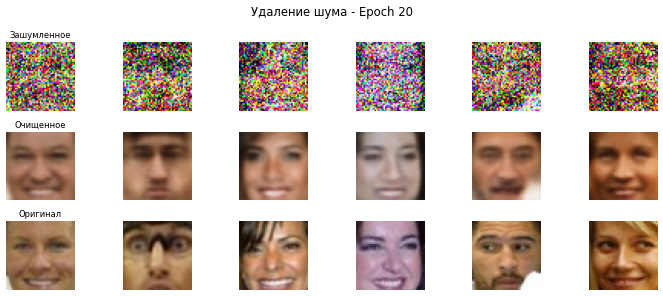

Epoch 21/60 | Train Loss: 0.0047 | Val Loss: 0.0058
Epoch 22/60 | Train Loss: 0.0046 | Val Loss: 0.0058
Epoch 23/60 | Train Loss: 0.0046 | Val Loss: 0.0058
Epoch 24/60 | Train Loss: 0.0045 | Val Loss: 0.0058
Epoch 25/60 | Train Loss: 0.0044 | Val Loss: 0.0060
Epoch 26/60 | Train Loss: 0.0043 | Val Loss: 0.0059
Epoch 27/60 | Train Loss: 0.0043 | Val Loss: 0.0058
Epoch 28/60 | Train Loss: 0.0042 | Val Loss: 0.0059
Epoch 29/60 | Train Loss: 0.0042 | Val Loss: 0.0058
Epoch 30/60 | Train Loss: 0.0041 | Val Loss: 0.0058
Epoch 31/60 | Train Loss: 0.0041 | Val Loss: 0.0059
Epoch 32/60 | Train Loss: 0.0040 | Val Loss: 0.0059
Epoch 33/60 | Train Loss: 0.0040 | Val Loss: 0.0059
Epoch 34/60 | Train Loss: 0.0039 | Val Loss: 0.0060
Epoch 35/60 | Train Loss: 0.0039 | Val Loss: 0.0059
Epoch 36/60 | Train Loss: 0.0038 | Val Loss: 0.0060
Epoch 37/60 | Train Loss: 0.0038 | Val Loss: 0.0060
Epoch 38/60 | Train Loss: 0.0038 | Val Loss: 0.0060
Epoch 39/60 | Train Loss: 0.0037 | Val Loss: 0.0060
Epoch 40/60 

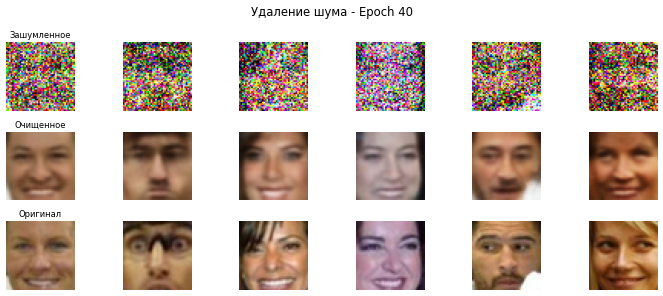

Epoch 41/60 | Train Loss: 0.0036 | Val Loss: 0.0061
Epoch 42/60 | Train Loss: 0.0036 | Val Loss: 0.0061
Epoch 43/60 | Train Loss: 0.0036 | Val Loss: 0.0062
Epoch 44/60 | Train Loss: 0.0036 | Val Loss: 0.0062
Epoch 45/60 | Train Loss: 0.0036 | Val Loss: 0.0063
Epoch 46/60 | Train Loss: 0.0035 | Val Loss: 0.0062
Epoch 47/60 | Train Loss: 0.0035 | Val Loss: 0.0063
Epoch 48/60 | Train Loss: 0.0035 | Val Loss: 0.0063
Epoch 49/60 | Train Loss: 0.0034 | Val Loss: 0.0063
Epoch 50/60 | Train Loss: 0.0034 | Val Loss: 0.0063
Epoch 51/60 | Train Loss: 0.0034 | Val Loss: 0.0064
Epoch 52/60 | Train Loss: 0.0034 | Val Loss: 0.0064
Epoch 53/60 | Train Loss: 0.0034 | Val Loss: 0.0064
Epoch 54/60 | Train Loss: 0.0033 | Val Loss: 0.0065
Epoch 55/60 | Train Loss: 0.0033 | Val Loss: 0.0064
Epoch 56/60 | Train Loss: 0.0033 | Val Loss: 0.0065
Epoch 57/60 | Train Loss: 0.0033 | Val Loss: 0.0065
Epoch 58/60 | Train Loss: 0.0033 | Val Loss: 0.0066
Epoch 59/60 | Train Loss: 0.0033 | Val Loss: 0.0065
Epoch 60/60 

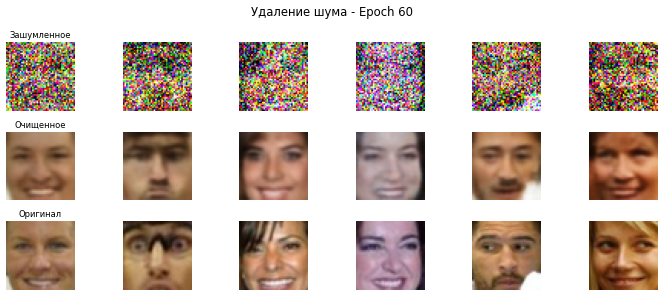

In [46]:
# Обучение

EPOCHS = 60

train_losses, val_losses = [], []

# Изображения для визуализации
VIZ_N = 6  # количество изображений для визуализации
viz_noisy = X_val_noisy[:VIZ_N].to(device)
viz_clean = X_val_t[:VIZ_N].to(device)

for epoch in range(1, EPOCHS + 1):
    # Трейн
    denoiser.train()
    train_loss = 0.0
    for batch_noisy, batch_clean in train_loader_noisy:
        batch_noisy = batch_noisy.to(device)
        batch_clean = batch_clean.to(device)
        
        optimizer.zero_grad()
        reconstruction, _ = denoiser(batch_noisy)
        loss = criterion(reconstruction, batch_clean)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader_noisy)
    train_losses.append(train_loss)
    
    # Валидация
    denoiser.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_noisy, batch_clean in val_loader_noisy:
            batch_noisy = batch_noisy.to(device)
            batch_clean = batch_clean.to(device)
            reconstruction, _ = denoiser(batch_noisy)
            val_loss += criterion(reconstruction, batch_clean).item()
    
    val_loss /= len(val_loader_noisy)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    
    # Визуализация удаления шума каждые 20 эпох
    if epoch % 20 == 0:
        with torch.no_grad():
            denoised, _ = denoiser(viz_noisy)
        
        fig, axes = plt.subplots(3, VIZ_N, figsize=(12, 5))
        for i in range(VIZ_N):
            # Зашумленное изображение
            axes[0, i].imshow(viz_noisy[i].cpu().permute(1, 2, 0))
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Зашумленное', fontsize=10)
            
            # Очищенное
            axes[1, i].imshow(denoised[i].cpu().permute(1, 2, 0))
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Очищенное', fontsize=10)
            
            # Оригинал
            axes[2, i].imshow(viz_clean[i].cpu().permute(1, 2, 0))
            axes[2, i].axis('off')
            if i == 0:
                axes[2, i].set_title('Оригинал', fontsize=10)
        
        plt.suptitle(f'Удаление шума - Epoch {epoch}', fontsize=14)
        plt.tight_layout()
        
        plt.show()

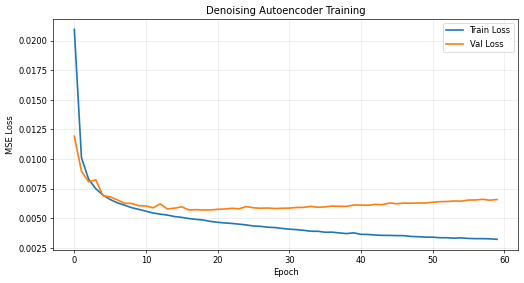

In [47]:
# Визуализация

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Denoising Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show();

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [48]:
# codes = <поучите латентные представления картинок из трейна>
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
autoencoder.eval()
codes = []
with torch.no_grad():
    for i in range(0, len(X_train_tensor), 256):  # обработка батчами по 256
        batch = X_train_tensor[i:i+256].to(device)
        _, z = autoencoder(batch) 
        codes.append(z.cpu().numpy())
codes = np.concatenate(codes, axis=0)

In [49]:
# Обучение индекса для 11 ближаших соседей
nn_index = NearestNeighbors(n_neighbors=11, metric='euclidean').fit(codes)

In [50]:
def get_similar(image, n_neighbors=11):
    """
    Поиск похожих изображений
    """
    image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
    with torch.no_grad():
        _, code = autoencoder(image_tensor.unsqueeze(0).to(device))
    code = code.cpu().numpy()
    distances, idx = nn_index.kneighbors(code, n_neighbors=n_neighbors)

    return distances[0], X_train[idx[0]]  # возвращаем расстояние до соседей и похожие изображения

In [51]:
def show_similar(image):
    """
    Визуализация оригинала и похожих изображений
    """
    distances,neighbors = get_similar(image,n_neighbors=11)

    fig, axes = plt.subplots(3, 4, figsize=(7, 5))
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Оригинал')
    axes[0, 0].axis('off')

    for i in range(11):
        row, col = divmod(i + 1, 4)
        axes[row, col].imshow(neighbors[i])
        axes[row, col].set_title(f'Dist={distances[i]:.3f}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

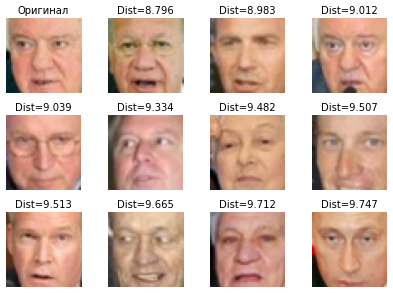

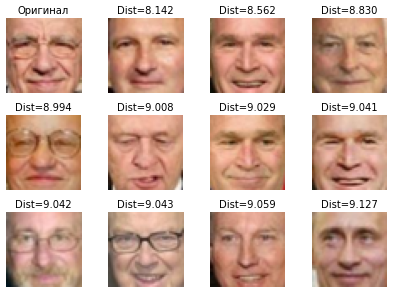

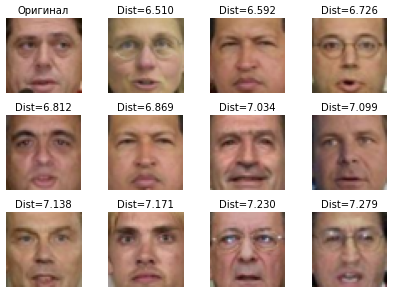

In [52]:
N_SAMPLES = 3

val_indices = np.random.randint(0, len(X_val), N_SAMPLES)

for i in val_indices:
    show_similar(X_val[i])